
# Amazon Health & Household Metadata – EDA 




In [0]:

df = (
    spark.read
        .option("multiLine", "false")
        .option("mode", "PERMISSIVE")
        .json("/Volumes/workspace/default/meta/health_household_filtered.jsonl")
)


In [0]:

df.printSchema()


root
 |-- average_rating: double (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- details: struct (nullable = true)
 |    |-- Brand: string (nullable = true)
 |    |-- Color: string (nullable = true)
 |    |-- Date First Available: string (nullable = true)
 |    |-- Item Form: string (nullable = true)
 |    |-- Item Weight: string (nullable = true)
 |    |-- Manufacturer: string (nullable = true)
 |    |-- Material: string (nullable = true)
 |    |-- Package Dimensions: string (nullable = true)
 |    |-- Product Dimensions: string (nullable = true)
 |    |-- Unit Count: string (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- main_category: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- price: double (nul

## 1. Dataset Size & Column Overview

In [0]:

from pyspark.sql.functions import col

print("Rows:", df.count())
print("Columns:", len(df.columns))
df.columns


Rows: 454816
Columns: 12


['average_rating',
 'bought_together',
 'categories',
 'description',
 'details',
 'features',
 'main_category',
 'parent_asin',
 'price',
 'rating_number',
 'store',
 'title']

## 2. Missing Value Analysis (ALL Columns)

In [0]:
numeric_types = ['float', 'double']
num_cols = [c for c, t in df.dtypes if t in numeric_types]

from pyspark.sql.functions import isnan, when, count, col

missing_df = df.select([
    count(when(col(c).isNull() | (isnan(col(c)) if c in num_cols else False), c)).alias(c)
    for c in df.columns
])

missing_df.show(truncate=False)

+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+
|average_rating|bought_together|categories|description|details|features|main_category|parent_asin|price |rating_number|store|title|
+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+
|0             |454816         |0         |0          |0      |0       |42836        |0          |258631|0            |3653 |0    |
+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+



In [0]:

total_rows = df.count()

missing_pct = missing_df.select([
    (col(c) / total_rows * 100).alias(c)
    for c in missing_df.columns
])

missing_pct.show(truncate=False)


+--------------+---------------+----------+-----------+-------+--------+-----------------+-----------+-----------------+-------------+------------------+-----+
|average_rating|bought_together|categories|description|details|features|main_category    |parent_asin|price            |rating_number|store             |title|
+--------------+---------------+----------+-----------+-------+--------+-----------------+-----------+-----------------+-------------+------------------+-----+
|0.0           |100.0          |0.0       |0.0        |0.0    |0.0     |9.418314219376626|0.0        |56.86497396749455|0.0          |0.8031819461056778|0.0  |
+--------------+---------------+----------+-----------+-------+--------+-----------------+-----------+-----------------+-------------+------------------+-----+




**Insight**
- Price, brand, weight, dimensions, and descriptive fields are sparsely populated.
- Structural sparsity is expected in Amazon metadata and must not be dropped blindly.


## 3. Numerical Columns EDA

In [0]:

num_cols = ["price", "average_rating", "rating_number"]

df.select(num_cols).describe().show()


+-------+-----------------+------------------+-----------------+
|summary|            price|    average_rating|    rating_number|
+-------+-----------------+------------------+-----------------+
|  count|           196185|            454816|           454816|
|   mean| 31.3950154700868| 4.148093075001865|319.9189430450996|
| stddev|98.08329292991016|0.6851595999269124|2679.629737002679|
|    min|             0.01|               1.0|                1|
|    max|          12158.0|               5.0|           726656|
+-------+-----------------+------------------+-----------------+



In [0]:

# Price distribution (excluding nulls)
df.select("price").where(col("price").isNotNull()).summary().show()


+-------+----------------+
|summary|           price|
+-------+----------------+
|  count|          196185|
|   mean|31.3950154700868|
| stddev|98.0832929299101|
|    min|            0.01|
|    25%|           11.99|
|    50%|           18.99|
|    75%|           29.99|
|    max|         12158.0|
+-------+----------------+




**Insight**
- Prices are heavily right-skewed.
- Majority of products cluster at low-to-mid price ranges.


## 4. Rating Behavior Analysis

In [0]:

df.groupBy("average_rating").count().orderBy("average_rating").show()


+--------------+-----+
|average_rating|count|
+--------------+-----+
|           1.0| 5313|
|           1.1|    5|
|           1.2|   40|
|           1.3|   90|
|           1.4|  145|
|           1.5|  352|
|           1.6|  181|
|           1.7|  203|
|           1.8|  217|
|           1.9|  290|
|           2.0| 2349|
|           2.1|  518|
|           2.2|  590|
|           2.3|  746|
|           2.4| 1005|
|           2.5| 1510|
|           2.6| 1487|
|           2.7| 1896|
|           2.8| 2419|
|           2.9| 3077|
+--------------+-----+
only showing top 20 rows


In [0]:

df.select("rating_number").where(col("rating_number") > 0).summary().show()


+-------+-----------------+
|summary|    rating_number|
+-------+-----------------+
|  count|           454816|
|   mean|319.9189430450996|
| stddev|2679.629737002679|
|    min|                1|
|    25%|                8|
|    50%|               29|
|    75%|              119|
|    max|           726656|
+-------+-----------------+




**Insight**
- High average ratings with low rating counts indicate possible bias.
- Rating volume is a stronger trust signal than rating value alone.


## 5. Category-Level Analysis

In [0]:

df.groupBy("main_category").count().orderBy(col("count").desc()).show(20, False)


+-------------------------+------+
|main_category            |count |
+-------------------------+------+
|Health & Personal Care   |255185|
|Amazon Home              |49471 |
|NULL                     |42836 |
|AMAZON FASHION           |38812 |
|Industrial & Scientific  |22280 |
|Tools & Home Improvement |13016 |
|Sports & Outdoors        |8771  |
|All Electronics          |7200  |
|Office Products          |5157  |
|Arts, Crafts & Sewing    |2579  |
|Computers                |1586  |
|Automotive               |1398  |
|Cell Phones & Accessories|1306  |
|All Beauty               |1076  |
|Home Audio & Theater     |979   |
|Pet Supplies             |962   |
|Musical Instruments      |607   |
|Grocery                  |486   |
|Camera & Photo           |444   |
|Appliances               |151   |
+-------------------------+------+
only showing top 20 rows



**Insight**
- Health & Household is dominated by a few high-volume subcategories.
- Long-tail categories contribute very few products.


## 6. Brand & Manufacturer Analysis

In [0]:

df.groupBy("details.Brand").count().orderBy(col("count").desc()).show(20, False)


+-------------------------+------+
|Brand                    |count |
+-------------------------+------+
|NULL                     |138787|
|Generic                  |2427  |
|Swanson                  |609   |
|Nutricost                |540   |
|GRAPHICS & MORE          |533   |
|HawaiiPharm              |515   |
|GNC                      |504   |
|Hallmark                 |477   |
|Secrets of the Tribe     |474   |
|Glade                    |452   |
|Gift Boutique            |422   |
|Amazon Basics            |414   |
|Caspari                  |406   |
|Creative Converting      |394   |
|Zippo                    |389   |
|UPS Battery Center       |387   |
|PURE ORIGINAL INGREDIENTS|386   |
|Carlyle                  |381   |
|Life Extension           |370   |
|Solimo                   |368   |
+-------------------------+------+
only showing top 20 rows



**Insight**
- Brand sparsity is high.
- Private-label or unbranded products dominate metadata.


## 7. Textual Feature Length Analysis

In [0]:

from pyspark.sql.functions import size, length

df.select(
    length(col("title")).alias("title_length"),
    size(col("description")).alias("description_length")
).summary().show()


+-------+------------------+------------------+
|summary|      title_length|description_length|
+-------+------------------+------------------+
|  count|            454816|            454816|
|   mean|126.13985215999438|1.6906001547878702|
| stddev|51.727372434177404| 5.579605853592312|
|    min|                 0|                 0|
|    25%|                82|                 0|
|    50%|               127|                 0|
|    75%|               173|                 1|
|    max|              1666|               623|
+-------+------------------+------------------+




**Insight**
- Titles are short and optimized for search.
- Descriptions vary widely, impacting NLP-based models.


## 8. Structural Field Analysis (Arrays & Structs)

In [0]:

df.select(
    size("categories").alias("num_categories"),
    size("features").alias("num_features")
).summary().show()


+-------+------------------+------------------+
|summary|    num_categories|      num_features|
+-------+------------------+------------------+
|  count|            454816|            454816|
|   mean| 4.253315626539084| 3.913391349468796|
| stddev|0.8774907384182238|2.4853240057632244|
|    min|                 2|                 0|
|    25%|                 4|                 2|
|    50%|                 4|                 5|
|    75%|                 5|                 5|
|    max|                 7|                19|
+-------+------------------+------------------+




**Insight**
- Most products belong to 1–3 categories.
- Feature richness is inconsistent across products.


## 9. Price vs Rating Relationship

In [0]:

df.select("price", "average_rating")   .where(col("price").isNotNull() & col("average_rating").isNotNull())   .summary().show()


+-------+----------------+------------------+
|summary|           price|    average_rating|
+-------+----------------+------------------+
|  count|          196185|            196185|
|   mean|31.3950154700868|     4.25086627418|
| stddev|98.0832929299101|0.5781698239905267|
|    min|            0.01|               1.0|
|    25%|           11.99|               4.0|
|    50%|           18.99|               4.4|
|    75%|           29.99|               4.6|
|    max|         12158.0|               5.0|
+-------+----------------+------------------+




**Insight**
- No strong linear relationship between price and rating.
- High-priced products are not necessarily better rated.


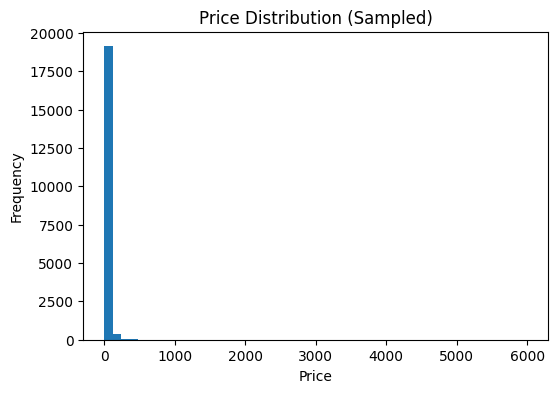

In [0]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

price_df = (
    df.select("price")
      .where(col("price").isNotNull())
      .where(col("price") > 0)
)

prices = price_df.sample(fraction=0.1, seed=42).toPandas()["price"]

plt.figure(figsize=(6,4))
plt.hist(prices, bins=50)
plt.title("Price Distribution (Sampled)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


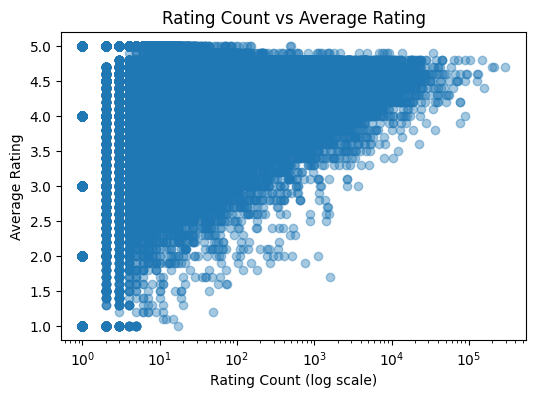

In [0]:
rating_df = (
    df.select("average_rating", "rating_number")
      .where(col("average_rating").isNotNull())
      .where(col("rating_number").isNotNull())
      .where(col("rating_number") > 0)
      .sample(0.2, seed=42)
      .toPandas()
)

plt.figure(figsize=(6,4))
plt.scatter(rating_df["rating_number"], rating_df["average_rating"], alpha=0.4)
plt.xscale("log")
plt.xlabel("Rating Count (log scale)")
plt.ylabel("Average Rating")
plt.title("Rating Count vs Average Rating")
plt.show()


# Insight

- High ratings with low counts are unreliable; rating volume is a stronger trust indicator.

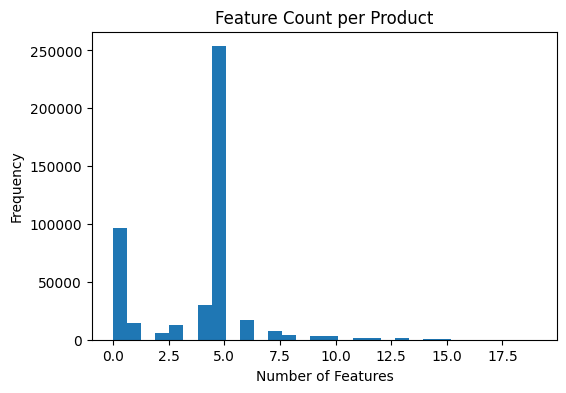

In [0]:
from pyspark.sql.functions import size

feature_df = (
    df.select(size("features").alias("num_features"))
      .where(col("num_features").isNotNull())
      .toPandas()
)

plt.figure(figsize=(6,4))
plt.hist(feature_df["num_features"], bins=30)
plt.title("Feature Count per Product")
plt.xlabel("Number of Features")
plt.ylabel("Frequency")
plt.show()


# Insight

- Feature richness varies widely, affecting downstream NLP and recommendation quality.

## 10. Key Business-Level Insights


- Metadata sparsity is structural, not noise.
- Rating count should be weighted more than rating value.
- Category imbalance must be handled before modeling.
- Price distributions require log-scaling for ML tasks.
- Text fields are suitable for NLP enrichment.
